### Submission 1. Plotting learning curve

In [37]:
%reload_ext autoreload
%autoreload 2

In [38]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

from spyglass.shijiegu.Analysis_SGU import TrialChoice,EpochPos,MUA,get_linearization_map, ChangeofMind
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename


In [41]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}
peak_day_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'
peak_day_animal[animal] = '20220420'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']
seq_animals[animal] = 'rev2'
peak_day_animal[animal] = '20240110'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'
peak_day_animal[animal] = '20221026'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'
peak_day_animal[animal] = '20230811'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']
seq_animals[animal] = 'rev2'
peak_day_animal[animal] = '20231108'

In [42]:
from spyglass.shijiegu.behavior import (return_pctCorrect, find_COM_trials, find_COM_trial_number,
        plot_learning_curve, plot_learning_curve_main)

In [46]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="behavior_parse_0")

[11:19:53][INFO] Spyglass: Starting {'export_id': 101}
INFO:spyglass:Starting {'export_id': 101}


In [47]:
pctCorrect_days, pctCorrect_days_sd, com_rates1, com_rates2, com_rates3 = {}, {}, {}, {}, {}
pctReward_days, pctReward_days_sd = {}, {}

for animal in seq_animals.keys():
    days_to_plot = list_of_days_animals[animal]
    (pctCorrect_days[animal], pctCorrect_days_sd[animal],
     pctReward_days[animal], pctReward_days_sd[animal]) = return_pctCorrect(animal, days_to_plot)
    com_rates1[animal] = find_COM_trials(animal,days_to_plot,proportion_threshold = 0.05)
    com_rates2[animal] = find_COM_trials(animal,days_to_plot,proportion_threshold = 0.1)
    com_rates3[animal] = find_COM_trials(animal,days_to_plot,proportion_threshold = 0.2)
    success_animal[animal] = 1

In [48]:
ExportSelection().stop_export(**paper_key, analysis_id="behavior_parse_0")

In [45]:
### save data
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
file_path = f"{output_folder}/figure1.pickle"

data = {"pctCorrect_days": pctCorrect_days, "pctCorrect_days_sd": pctCorrect_days_sd,
        "pctReward_days": pctReward_days, "pctReward_days_sd":pctReward_days_sd,
     "com_rates1": com_rates1, "com_rates2": com_rates2, "com_rates3": com_rates3}
with open(file_path, 'wb') as file:
    pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {file_path}")

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/figure1.pickle


### Plotting

In [10]:
data_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
file_path = f"{data_folder}/figure1.pickle"

with open(file_path, 'rb') as file:
    data = pickle.load(file)

pctCorrect_days, pctCorrect_days_sd = data["pctCorrect_days"], data["pctCorrect_days_sd"]
com_rates1, com_rates2, com_rates3 = data["com_rates1"], data["com_rates2"], data["com_rates3"]
pctReward_days = data["pctReward_days"]
pctReward_days_sd = data["pctReward_days_sd"]

### For main text

#### a) learning curve

In [11]:
pctCorrect_days[animal]

{'20231101': array([0.3369458 , 0.26780511, 0.28729228, 0.36279445, 0.40822376,
        0.32827444]),
 '20231102': array([0.37737276, 0.30180369, 0.30184149, 0.39079905, 0.34515345,
        0.27764393]),
 '20231103': array([0.41624, 0.265  , 0.30266, 0.28918, 0.44576, 0.27572]),
 '20231104': array([0.35  , 0.32  , 0.325 , 0.3975, 0.345 , 0.2525]),
 '20231105': array([0.30625 , 0.2125  , 0.309375, 0.50625 , 0.421875, 0.24375 ]),
 '20231106': array([0.315625, 0.203125, 0.3     , 0.396875, 0.459375, 0.325   ]),
 '20231107': array([0.3675, 0.26  , 0.3425, 0.365 , 0.4275, 0.2275]),
 '20231108': array([0.346875, 0.19375 , 0.296875, 0.303125, 0.578125, 0.28125 ])}

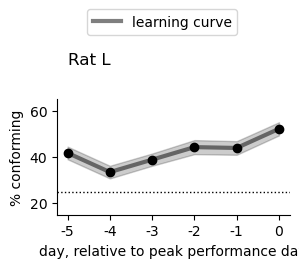

In [36]:
output_folder = '/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1'
animal = "lewis"

if seq_animals[animal] == "rev2":
    target_seq_ind = 4
else:
    target_seq_ind = 1

plot_learning_curve_main(animal,
     pctCorrect_days[animal], pctCorrect_days_sd[animal],
     com_rates2[animal], peak_day_animal[animal],
     target_seq_ind,
     os.path.join(output_folder,f"Learning_curve_{animal}_maintext.pdf"))

#### b) cumulative change of mind number of trials vs total number of trials

In [7]:
num_all_animals = {}
num_com_animals = {}
for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    trial_number, com_number, reward_number = find_COM_trial_number(animal, list_of_days_animals[animal], proportion_threshold = 0.1)
    num_all_animals[animal] = np.sum(trial_number)
    num_com_animals[animal] = np.sum(com_number)
    #num_reward = np.sum(reward_number)

In [8]:
from spyglass.shijiegu.changeOfMind import color_by_rat

In [ ]:
output_folder = '/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1'
savename = os.path.join(output_folder,f"Number_of_trials_maintext.pdf")

fig, axes = plt.subplots(1, 1, figsize=(2, 2),sharex=True)
for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    x, y = num_all_animals[animal], num_com_animals[animal]
    axes.scatter(x, y, s= 80, color = color_by_rat[animal])
    #axes.text(x-60, y-8, f"{animal[0].upper()}", color = "white", color = )
axes.set_xlim([0, 5000])
axes.set_ylim([0, 350])
axes.set_xlabel("# of trials")
axes.set_ylabel("# com trials")
axes.spines[['right', 'top']].set_visible(False)
plt.savefig(savename,bbox_inches='tight',dpi = 300)

In [10]:
num_com_animals

{'molly': 107, 'eliot': 225, 'julio': 138, 'klein': 315, 'lewis': 309}

### For supplementary

[[0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], 'C1', [0.6, 0.6, 0.6]]


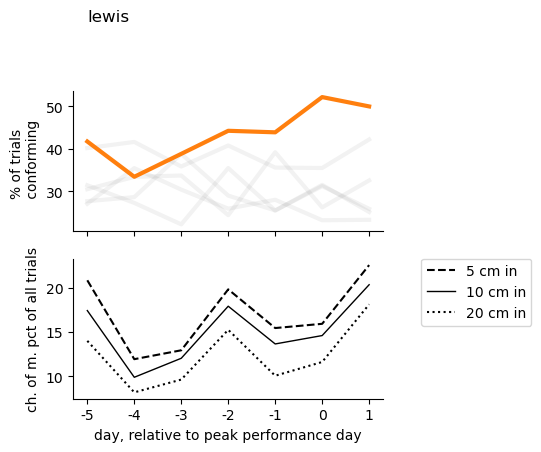

In [56]:
output_folder = '/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1'
animal = "lewis"

if seq_animals[animal] == "rev2":
    target_seq_ind = 4
else:
    target_seq_ind = 1
        
plot_learning_curve(animal,
     pctCorrect_days[animal], pctCorrect_days_sd[animal],
     com_rates1[animal], com_rates2[animal], com_rates3[animal], peak_day_animal[animal],
     target_seq_ind, os.path.join(output_folder,f"Learning_curve_{animal}.pdf"))

## End here

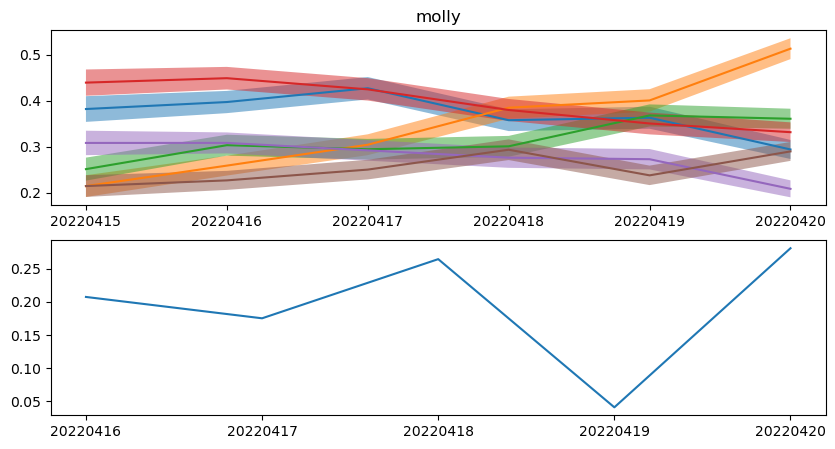

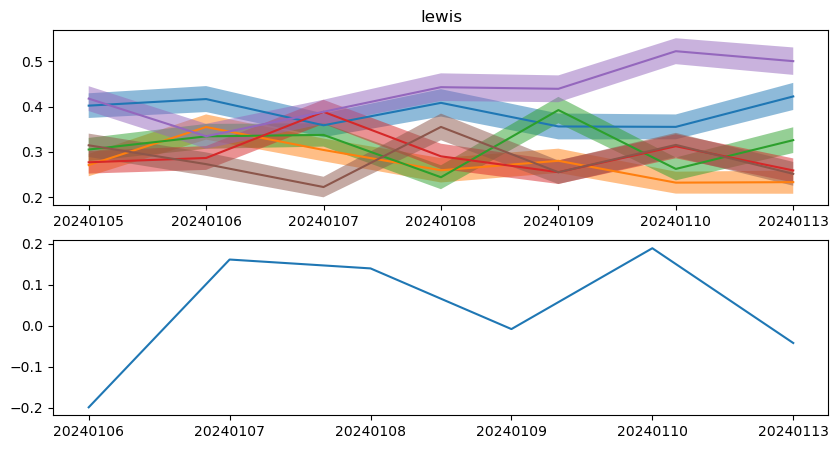

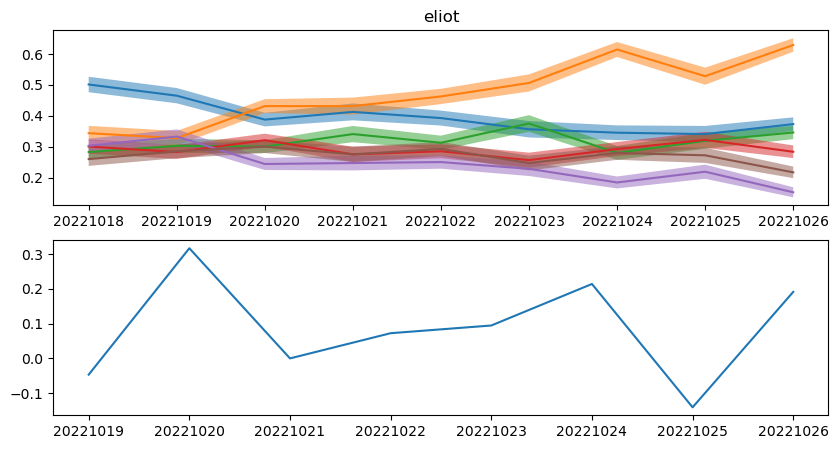

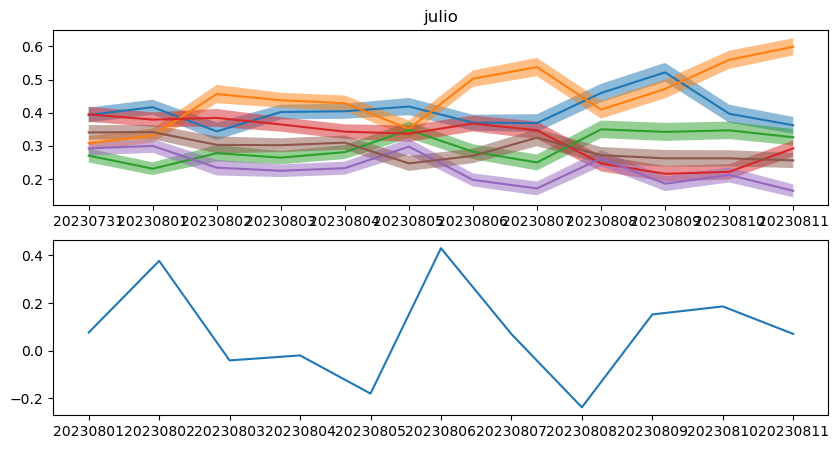

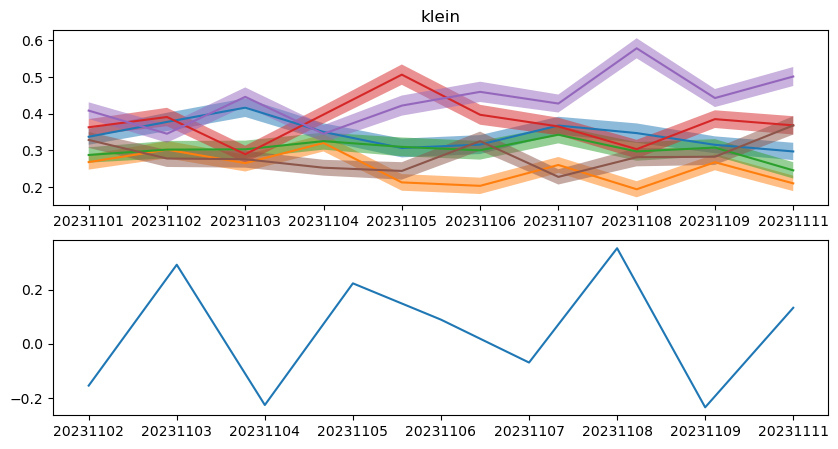

In [138]:
for animal in seq_animals.keys():
    mean_data = pctCorrect_days[animal]
    sd_data = pctCorrect_days_sd[animal]
    
    fig, axes = plt.subplots(2,1,figsize = (10,5))
    
    days = list(mean_data.keys())
    if seq_animals[animal] == "rev2":
        target_seq_ind = 4
    else:
        target_seq_ind = 1
        
    for seq_ind in range(6):
        y = np.array( [mean_data[k][seq_ind] for k in mean_data] )
        sd = np.array( [sd_data[k][seq_ind] for k in sd_data] )
        axes[0].plot(days, y)
        axes[0].fill_between(days, y - sd, y + sd, alpha = 0.5)
        
    y_taget = [mean_data[k][target_seq_ind] for k in mean_data]
    axes[1].plot(days[1:],np.diff(y_taget)/y_taget[:-1])
    axes[0].set_title(animal)


Once rat behavior becomes predominantly aligned with the correct sequence, we overtrain rats for another few days. 
We include all the data from early learning (1-2 days of low correct sequence transitions performance) to peak of performance day.